<a href="https://colab.research.google.com/github/AhmadMugiar/Materi_Pertemuan2_AsistenPraktikum_SBD/blob/main/Prak_SBD_Nama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PERTEMUAN 3**

##IMPORT LIBRARY

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 469.0 kB/s eta 0:00:00


In [ ]:
from google_play_scraper import app, reviews
import pandas as pd
import numpy as np
from google_play_scraper import Sort, reviews
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
import requests
import json

In [ ]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 14.7 MB/s eta 0:00:00


In [ ]:
!pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

##Scraping Data Reviews

In [ ]:
result, continuation_token = reviews(
    'com.kai.kaiticketing',
    lang='id',
    country='id',
    sort=Sort.MOST_RELEVANT,
    count=500,
    filter_score_with= None
)

In [ ]:
data = pd.DataFrame(np.array(result),columns=['review'])
data = data.join(pd.DataFrame(data.pop('review').tolist()))
data

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,a6f5311e-897c-44e8-a7fb-b35599bb5a1a,laura novalisa1117,https://play-lh.googleusercontent.com/a/ACg8oc...,"apk paling aneh, untuk daftar member basic aja...",1,2,6.19.6,2026-09-09 17:21:10,None,NaT,6.19.6
1,878741e2-15c6-4723-9210-1bd942d4329a,Nurkholis Elbazar,https://play-lh.googleusercontent.com/a-/ALV-U...,"Ada sisa kursi 2, ketika dipilih respon dari a...",1,12,6.19.6,2026-08-15 03:05:19,None,NaT,6.19.6
2,bd474277-8934-43eb-88be-e4f13861173f,Avril Maulindaa,https://play-lh.googleusercontent.com/a/ACg8oc...,"jujur aku suka sama aplikasi ini, tapi kenapa ...",1,14,6.19.5,2026-08-09 17:29:33,None,NaT,6.19.5
3,d1d76e50-85e3-4245-b691-f70a3fd58a79,rifa fachri,https://play-lh.googleusercontent.com/a/ACg8oc...,disatu sisi aplikasi ini memang bagus untuk me...,3,10,6.19.5,2026-08-06 10:17:54,None,NaT,6.19.5
4,ad3c4ef6-39b6-4ef7-8a70-5b7d3269a397,Jaja Mujahidin,https://play-lh.googleusercontent.com/a-/ALV-U...,untuk pesan tiket lokal masih ok lah tidak ada...,3,3,6.19.6,2026-09-02 16:13:23,None,NaT,6.19.6
...,...,...,...,...,...,...,...,...,...,...,...
495,c4b437fe-b7ad-4f69-988a-6bc6c98d167b,Vela Wahyu,https://play-lh.googleusercontent.com/a/ACg8oc...,kenapa yaa kai kalau udah sore sampek malam pa...,2,0,6.18.4,2026-06-04 10:42:37,None,NaT,6.18.4
496,945add24-98cd-488b-8b8b-af6d9594fcd0,Gugun,https://play-lh.googleusercontent.com/a-/ALV-U...,KLO dari aplikasi KAI nya oke bgt sih mempermu...,4,1,6.18.0,2026-04-20 05:49:40,None,NaT,6.18.0
497,7d0bb6b2-1d58-4d53-9cfb-101bba7b2f79,Wahyu Ramadhani,https://play-lh.googleusercontent.com/a/ACg8oc...,"setiap kali mndekati jam berangkat, aplikasi e...",1,2,6.18.4,2026-06-12 11:34:39,None,NaT,6.18.4
498,d4eb5633-f2d9-41ba-bbb7-a8ddd6a5bea6,NUR HADI,https://play-lh.googleusercontent.com/a-/ALV-U...,saat buka aplikasi mau pesen tiket jadwal sela...,1,1,6.18.4,2026-06-03 16:00:14,None,NaT,6.18.4


##Data Understanding

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              500 non-null    object        
 1   userName              500 non-null    object        
 2   userImage             500 non-null    object        
 3   content               500 non-null    object        
 4   score                 500 non-null    int64         
 5   thumbsUpCount         500 non-null    int64         
 6   reviewCreatedVersion  500 non-null    object        
 7   at                    500 non-null    datetime64[ns]
 8   replyContent          9 non-null      object        
 9   repliedAt             9 non-null      datetime64[ns]
 10  appVersion            500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 43.1+ KB


In [ ]:
data.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,0
at,0
replyContent,491
repliedAt,491


In [ ]:
data.describe()

,score,thumbsUpCount,at,repliedAt
count,500.000000,500.000000,500,9
mean,2.110000,2.410000,2026-07-23 23:24:01.537999872,2024-03-13 14:35:40.777777920
min,1.000000,0.000000,2026-04-18 13:08:08,2023-08-07 03:01:24
25%,1.000000,0.000000,2026-06-28 13:54:06,2023-08-25 03:52:29
50%,1.000000,1.000000,2026-08-06 16:35:36.500000,2023-10-20 02:32:02
75%,3.000000,2.000000,2026-08-11 16:00:20.500000,2024-03-15 02:27:14
max,5.000000,54.000000,2026-09-19 02:14:34,2026-07-26 02:08:53
std,1.471813,5.017994,NaN,NaN


In [ ]:
data = data[['reviewId','content','score','at']]
data.head()

,reviewId,content,score,at
0,a6f5311e-897c-44e8-a7fb-b35599bb5a1a,"apk paling aneh, untuk daftar member basic aja...",1,2026-09-09 17:21:10
1,878741e2-15c6-4723-9210-1bd942d4329a,"Ada sisa kursi 2, ketika dipilih respon dari a...",1,2026-08-15 03:05:19
2,bd474277-8934-43eb-88be-e4f13861173f,"jujur aku suka sama aplikasi ini, tapi kenapa ...",1,2026-08-09 17:29:33
3,d1d76e50-85e3-4245-b691-f70a3fd58a79,disatu sisi aplikasi ini memang bagus untuk me...,3,2026-08-06 10:17:54
4,ad3c4ef6-39b6-4ef7-8a70-5b7d3269a397,untuk pesan tiket lokal masih ok lah tidak ada...,3,2026-09-02 16:13:23


In [ ]:
len(data)

500

In [ ]:
data.tail(20)

,reviewId,content,score,at
480,7276e78f-f703-4a95-b765-f467717ce001,"saya mau batalin tiket saya tapi gabisa, katan...",3,2026-05-31 12:54:43
481,b717111d-1077-4bac-8579-e2bf2c925bfc,Buruk sangat buruk .. Reload sangat lama . Bah...,5,2026-05-23 08:51:13
482,6ad98e5b-6155-49dd-968c-9b453312d9e0,"setelah update, jadwal tiket kereta sering ga ...",1,2026-05-27 06:35:44
483,ddb29cb4-cb46-4e85-b28e-ff4bd88ec70f,saat akan pesan tiket kereta lokal tiba - tiba...,1,2026-06-04 17:14:02
484,fa8305e6-4742-48a7-8ce2-d00ef16b3685,"aplikasi buruk, masa mau pesen tiket ga bisa, ...",1,2026-06-04 07:19:04
485,1ebb819f-9fe9-4c9d-94cc-32f38e8772f9,"apalah beberapa kali cari tiket, tiba-tiba gak...",2,2026-05-30 22:12:23
486,4d048c73-b7ed-4b7f-8a02-7294a1032a7e,mempersulit yang mudah. Biasa nya bisa pesen t...,1,2026-05-17 04:44:50
487,15943299-24ae-41af-b25f-0226050e3a5f,"makin lama aplikasinya ga berbenah, udah banya...",2,2026-05-24 19:12:43
488,c3be9c4f-2783-41e9-873c-215b8e2cc178,aplikasinya kenawhy gak jelas sik sekarang tuh...,1,2026-05-22 05:44:42
489,29901e3a-2ae5-42ed-bf51-2ff99add76ea,aplikasinya sekarang g jelas jadwal selalu dal...,1,2026-05-23 16:55:35


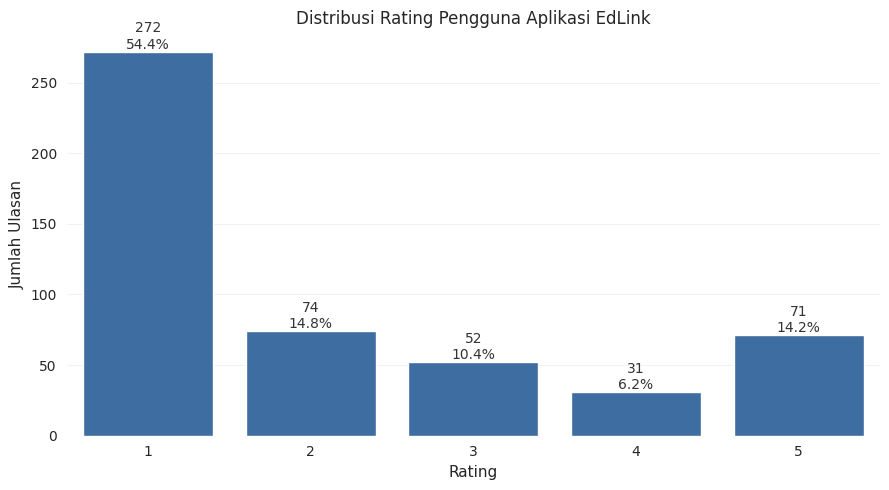

In [ ]:
plt.figure(figsize=(9, 5))
sns.set_style("whitegrid")

order = sorted(data['score'].unique())
ax = sns.countplot(
    x='score',
    data=data,
    order=order,
    color="#2C6DB2",
)

total = len(data)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}\n{height/total*100:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=10,
        color='#333333'
    )

plt.title(
    'Distribusi Rating Pengguna Aplikasi EdLink')
plt.xlabel('Rating', fontsize=11)
plt.ylabel('Jumlah Ulasan', fontsize=11)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

sns.despine(left=True, bottom=True)
plt.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

In [ ]:
data['Tanggal Reviews'] = pd.to_datetime(data['at'])
data['month'] = data['Tanggal Reviews'].dt.month
review_year_score = (
    data.groupby(['month', 'score'])
      .size()
      .reset_index(name='Jumlah Ulasan'))

/tmp/ipykernel_782/4107384460.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Tanggal Reviews'] = pd.to_datetime(data['at'])
/tmp/ipykernel_782/4107384460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['month'] = data['Tanggal Reviews'].dt.month


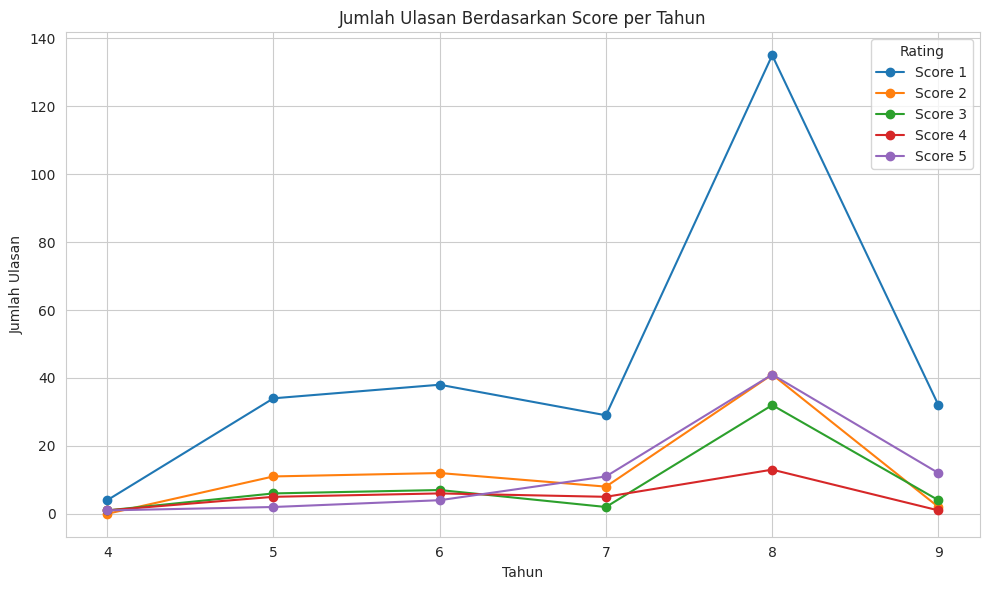

In [ ]:
pivot_df = review_year_score.pivot(
    index='month',
    columns='score',
    values='Jumlah Ulasan'
).fillna(0)
plt.figure(figsize=(10, 6))

for score in pivot_df.columns:
    plt.plot(
        pivot_df.index,
        pivot_df[score],
        marker='o',
        label=f'Score {int(score)}')
plt.title('Jumlah Ulasan Berdasarkan Score per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Ulasan')
plt.legend(title='Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_782/3983986821.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['token_count'] = data['content'].apply(lambda x: len(x.split()))


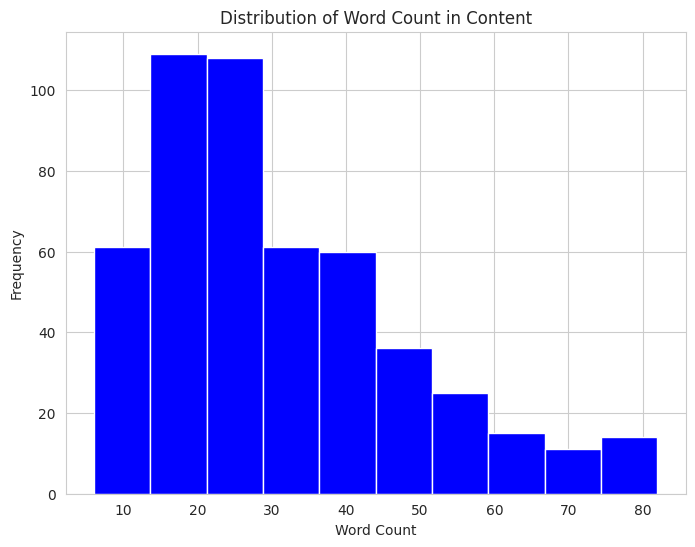

In [ ]:
data['token_count'] = data['content'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 6))
plt.hist(data['token_count'], bins=10, color='blue')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Count in Content')
plt.grid(True)
plt.show()

/tmp/ipykernel_782/244852279.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Review Length'] = data['content'].apply(len)


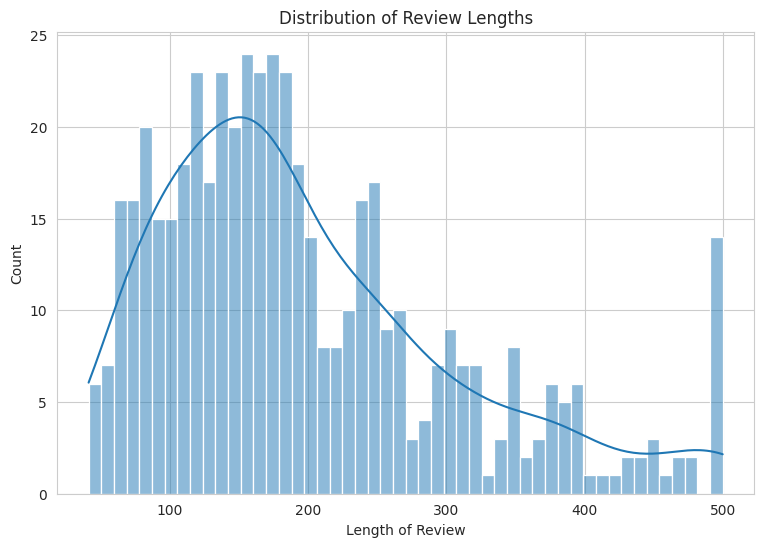

In [ ]:
data['Review Length'] = data['content'].apply(len)
plt.figure(figsize=(9, 6))
sns.histplot(data['Review Length'], bins=50, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Length of Review')
plt.ylabel('Count')
plt.show()

In [ ]:
data.to_csv("dataset_reviews_scrper_gplay.csv",index=False)

##Data Preprocessing

In [ ]:
df = pd.read_csv("/content/dataset_reviews_scrper_gplay.csv")
df

,reviewId,content,score,at,Tanggal Reviews,month,token_count,Review Length
0,a6f5311e-897c-44e8-a7fb-b35599bb5a1a,"apk paling aneh, untuk daftar member basic aja...",1,2026-09-09 17:21:10,2026-09-09 17:21:10,9,45,301
1,878741e2-15c6-4723-9210-1bd942d4329a,"Ada sisa kursi 2, ketika dipilih respon dari a...",1,2026-08-15 03:05:19,2026-08-15 03:05:19,8,44,299
2,bd474277-8934-43eb-88be-e4f13861173f,"jujur aku suka sama aplikasi ini, tapi kenapa ...",1,2026-08-09 17:29:33,2026-08-09 17:29:33,8,79,465
3,d1d76e50-85e3-4245-b691-f70a3fd58a79,disatu sisi aplikasi ini memang bagus untuk me...,3,2026-08-06 10:17:54,2026-08-06 10:17:54,8,76,500
4,ad3c4ef6-39b6-4ef7-8a70-5b7d3269a397,untuk pesan tiket lokal masih ok lah tidak ada...,3,2026-09-02 16:13:23,2026-09-02 16:13:23,9,79,493
...,...,...,...,...,...,...,...,...
495,c4b437fe-b7ad-4f69-988a-6bc6c98d167b,kenapa yaa kai kalau udah sore sampek malam pa...,2,2026-06-04 10:42:37,2026-06-04 10:42:37,6,27,176
496,945add24-98cd-488b-8b8b-af6d9594fcd0,KLO dari aplikasi KAI nya oke bgt sih mempermu...,4,2026-04-20 05:49:40,2026-04-20 05:49:40,4,35,194
497,7d0bb6b2-1d58-4d53-9cfb-101bba7b2f79,"setiap kali mndekati jam berangkat, aplikasi e...",1,2026-06-12 11:34:39,2026-06-12 11:34:39,6,21,141
498,d4eb5633-f2d9-41ba-bbb7-a8ddd6a5bea6,saat buka aplikasi mau pesen tiket jadwal sela...,1,2026-06-03 16:00:14,2026-06-03 16:00:14,6,25,173


In [ ]:
data = df[['content']]
data

,content
0,"apk paling aneh, untuk daftar member basic aja..."
1,"Ada sisa kursi 2, ketika dipilih respon dari a..."
2,"jujur aku suka sama aplikasi ini, tapi kenapa ..."
3,disatu sisi aplikasi ini memang bagus untuk me...
4,untuk pesan tiket lokal masih ok lah tidak ada...
...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...
497,"setiap kali mndekati jam berangkat, aplikasi e..."
498,saat buka aplikasi mau pesen tiket jadwal sela...


##Text Cleansing

In [ ]:
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'-', ' ', tweet)               # "dan lain-lain" → "dan lain lain"
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)  # hapus simbol lainnya
        tweet = re.sub(r'\s+', ' ', tweet).strip()     # rapikan spasi berlebih
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

# Fungsi hapus username
def remove_usernames(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'@\w+', '', text)
    else:
        return text

data = pd.DataFrame(data[['content']])

data['processed_review'] = data['content'].apply(lambda x: remove_URL(x))
data['processed_review'] = data['processed_review'].apply(lambda x: remove_usernames(x))
data['processed_review'] = data['processed_review'].apply(lambda x: remove_html(x))
data['processed_review'] = data['processed_review'].apply(lambda x: remove_emoji(x))
data['processed_review'] = data['processed_review'].apply(lambda x: remove_symbols(x))
data['processed_review'] = data['processed_review'].apply(lambda x: remove_numbers(x))

data

,content,processed_review
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",Ada sisa kursi ketika dipilih respon dari apl...
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...
...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,KLO dari aplikasi KAI nya oke bgt sih mempermu...
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...


##Casefolding

In [ ]:
def casefolding(text):
    if text is not None and isinstance(text, str):
        return text.lower()
    else:
        return text
data['processed_review'] = data['processed_review'].apply(lambda x: casefolding(x))
data


,content,processed_review
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",ada sisa kursi ketika dipilih respon dari apl...
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...
...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,klo dari aplikasi kai nya oke bgt sih mempermu...
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...


##Tokenization

In [ ]:
def tokenize(text):
    return text.split()
data['tokens'] = data['processed_review'].apply(tokenize)
data

,content,processed_review,tokens
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...,"[apk, paling, aneh, untuk, daftar, member, bas..."
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",ada sisa kursi ketika dipilih respon dari apl...,"[ada, sisa, kursi, ketika, dipilih, respon, da..."
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...,"[jujur, aku, suka, sama, aplikasi, ini, tapi, ..."
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...,"[disatu, sisi, aplikasi, ini, memang, bagus, u..."
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...,"[untuk, pesan, tiket, lokal, masih, ok, lah, t..."
...,...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...,"[kenapa, yaa, kai, kalau, udah, sore, sampek, ..."
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,klo dari aplikasi kai nya oke bgt sih mempermu...,"[klo, dari, aplikasi, kai, nya, oke, bgt, sih,..."
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...,"[setiap, kali, mndekati, jam, berangkat, aplik..."
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...,"[saat, buka, aplikasi, mau, pesen, tiket, jadw..."


In [ ]:
all_tokens = [token for sublist in data['tokens'] for token in sublist]
appearance = nltk.FreqDist(all_tokens)
print(appearance.most_common())

[('tiket', 340), ('di', 297), ('bisa', 275), ('aplikasi', 251), ('tidak', 214), ('ada', 197), ('saya', 181), ('dan', 170), ('mau', 167), ('ini', 150), ('kereta', 141), ('nya', 141), ('ga', 139), ('lagi', 137), ('yang', 137), ('tapi', 116), ('untuk', 113), ('gak', 111), ('malah', 107), ('jadwal', 107), ('tolong', 105), ('kai', 98), ('padahal', 94), ('ke', 92), ('sudah', 88), ('pesan', 87), ('lama', 87), ('udah', 84), ('banget', 80), ('jadi', 78), ('yg', 78), ('aja', 75), ('sering', 75), ('juga', 73), ('update', 71), ('beli', 67), ('aplikasinya', 67), ('sama', 66), ('terus', 66), ('error', 63), ('kenapa', 61), ('masuk', 61), ('muncul', 60), ('kursi', 59), ('pas', 58), ('masih', 56), ('harus', 56), ('buat', 56), ('lebih', 55), ('sangat', 55), ('jam', 55), ('perbaiki', 54), ('dari', 53), ('saat', 52), ('susah', 51), ('penumpang', 49), ('akun', 49), ('bagus', 48), ('tiba', 48), ('kali', 47), ('apk', 46), ('setelah', 46), ('makin', 46), ('banyak', 45), ('ya', 45), ('apa', 45), ('tersedia', 4

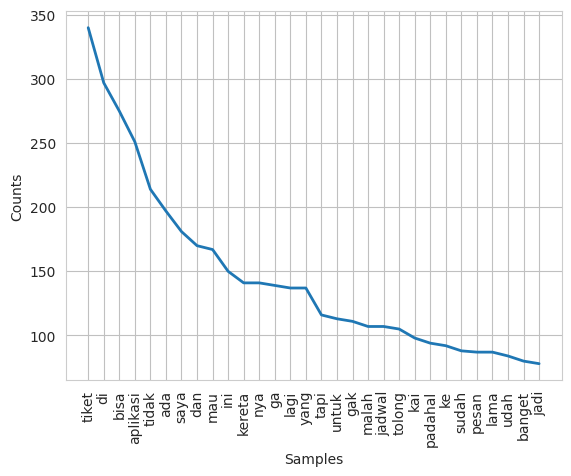

In [ ]:
appearance.plot(30,cumulative=False)
plt.show()

##Normalization

In [ ]:
url = "https://raw.githubusercontent.com/onpilot/sentimen-bahasa/master/kamus/nasalsabila_kamus-alay/_json_colloquial-indonesian-lexicon.txt"
response = requests.get(url)
slang_dict = json.loads(response.text)
def handle_slang(tokens):
    return [slang_dict.get(word, word) for word in tokens]
data['normalization'] = data['tokens'].apply(handle_slang)
data

,content,processed_review,tokens,normalization
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...,"[apk, paling, aneh, untuk, daftar, member, bas...","[apk, paling, aneh, untuk, daftar, member, bas..."
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",ada sisa kursi ketika dipilih respon dari apl...,"[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respon, da..."
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...,"[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tapi, ..."
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...,"[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, sisi, aplikasi, ini, memang, bagus, u..."
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...,"[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[untuk, pesan, tiket, lokal, masih, ok, lah, t..."
...,...,...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...,"[kenapa, yaa, kai, kalau, udah, sore, sampek, ...","[kenapa, ya, kai, kalau, sudah, sore, sampai, ..."
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,klo dari aplikasi kai nya oke bgt sih mempermu...,"[klo, dari, aplikasi, kai, nya, oke, bgt, sih,...","[kalo, dari, aplikasi, kai, nya, oke, banget, ..."
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...,"[setiap, kali, mndekati, jam, berangkat, aplik...","[setiap, kali, mndekati, jam, berangkat, aplik..."
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...,"[saat, buka, aplikasi, mau, pesen, tiket, jadw...","[saat, buka, aplikasi, mau, pesan, tiket, jadw..."


In [ ]:
alay_dict = pd.read_csv(
    '/content/new_kamusalay.csv',
    names=['original', 'replacement'],
    encoding='latin-1'
)
alay_dict_map = dict(zip(alay_dict['original'], alay_dict['replacement']))

In [ ]:
with open('/content/combined_slang_words.txt', 'r', encoding='utf-8') as file:
    slang_dict_txt = json.load(file)

In [ ]:
combined_slang_dict = {**alay_dict_map, **slang_dict_txt}
def normalize_slang(tokens):
    return [combined_slang_dict.get(token, token) for token in tokens]

In [ ]:
data['processed_tokenized'] = data['tokens'].apply(normalize_slang)
data

,content,processed_review,tokens,normalization,processed_tokenized
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...,"[apk, paling, aneh, untuk, daftar, member, bas...","[apk, paling, aneh, untuk, daftar, member, bas...","[aplikasi, paling, aneh, buat, daftar, member,..."
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",ada sisa kursi ketika dipilih respon dari apl...,"[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respons ta..."
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...,"[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tetapi..."
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...,"[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, samping, aplikasi, ini, memang, bagus..."
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...,"[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[buat, pesan, tiket, lokal, masih, ok, saja, t..."
...,...,...,...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...,"[kenapa, yaa, kai, kalau, udah, sore, sampek, ...","[kenapa, ya, kai, kalau, sudah, sore, sampai, ...","[kenapa, ya, kau, kalau, sudah, petang, sampai..."
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,klo dari aplikasi kai nya oke bgt sih mempermu...,"[klo, dari, aplikasi, kai, nya, oke, bgt, sih,...","[kalo, dari, aplikasi, kai, nya, oke, banget, ...","[kalau, dari, aplikasi, kau, dia, oke, banget,..."
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...,"[setiap, kali, mndekati, jam, berangkat, aplik...","[setiap, kali, mndekati, jam, berangkat, aplik...","[tiap, kali, mndekati, jam, berangkat, aplikas..."
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...,"[saat, buka, aplikasi, mau, pesen, tiket, jadw...","[saat, buka, aplikasi, mau, pesan, tiket, jadw...","[ketika, buka, aplikasi, mau, pesan, tiket, ja..."


In [ ]:
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

data['stopwords'] = data['processed_tokenized'].apply(remove_stopwords)
data

,content,processed_review,tokens,normalization,processed_tokenized,stopwords
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...,"[apk, paling, aneh, untuk, daftar, member, bas...","[apk, paling, aneh, untuk, daftar, member, bas...","[aplikasi, paling, aneh, buat, daftar, member,...","[aplikasi, paling, aneh, buat, daftar, member,..."
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",ada sisa kursi ketika dipilih respon dari apl...,"[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respons ta...","[sisa, kursi, dipilih, respons tanggapan, apli..."
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...,"[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tetapi...","[jujur, aku, suka, sama, aplikasi, iya, buat, ..."
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...,"[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, samping, aplikasi, ini, memang, bagus...","[disatu, samping, aplikasi, memang, bagus, bua..."
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...,"[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[buat, pesan, tiket, lokal, masih, ok, saja, t...","[buat, pesan, tiket, lokal, kendala, buat, pes..."
...,...,...,...,...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...,"[kenapa, yaa, kai, kalau, udah, sore, sampek, ...","[kenapa, ya, kai, kalau, sudah, sore, sampai, ...","[kenapa, ya, kau, kalau, sudah, petang, sampai...","[kau, kalau, petang, malam, tulisanya, aplikas..."
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,klo dari aplikasi kai nya oke bgt sih mempermu...,"[klo, dari, aplikasi, kai, nya, oke, bgt, sih,...","[kalo, dari, aplikasi, kai, nya, oke, banget, ...","[kalau, dari, aplikasi, kau, dia, oke, banget,...","[kalau, aplikasi, kau, oke, banget, partikel p..."
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...,"[setiap, kali, mndekati, jam, berangkat, aplik...","[setiap, kali, mndekati, jam, berangkat, aplik...","[tiap, kali, mndekati, jam, berangkat, aplikas...","[tiap, kali, mndekati, jam, berangkat, aplikas..."
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...,"[saat, buka, aplikasi, mau, pesen, tiket, jadw...","[saat, buka, aplikasi, mau, pesan, tiket, jadw...","[ketika, buka, aplikasi, mau, pesan, tiket, ja...","[buka, aplikasi, mau, pesan, tiket, jadwal, se..."


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()
def stem_tokens(tokens):
    return [stemmer.stem(word) for word in tokens]
data['stemmed'] = data['stopwords'].apply(stem_tokens)
data

,content,processed_review,tokens,normalization,processed_tokenized,stopwords,stemmed
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...,"[apk, paling, aneh, untuk, daftar, member, bas...","[apk, paling, aneh, untuk, daftar, member, bas...","[aplikasi, paling, aneh, buat, daftar, member,...","[aplikasi, paling, aneh, buat, daftar, member,...","[aplikasi, paling, aneh, buat, daftar, member,..."
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",ada sisa kursi ketika dipilih respon dari apl...,"[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respons ta...","[sisa, kursi, dipilih, respons tanggapan, apli...","[sisa, kursi, pilih, respons tanggap, aplikasi..."
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...,"[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tetapi...","[jujur, aku, suka, sama, aplikasi, iya, buat, ...","[jujur, aku, suka, sama, aplikasi, iya, buat, ..."
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...,"[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, samping, aplikasi, ini, memang, bagus...","[disatu, samping, aplikasi, memang, bagus, bua...","[satu, samping, aplikasi, memang, bagus, buat,..."
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...,"[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[buat, pesan, tiket, lokal, masih, ok, saja, t...","[buat, pesan, tiket, lokal, kendala, buat, pes...","[buat, pesan, tiket, lokal, kendala, buat, pes..."
...,...,...,...,...,...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...,"[kenapa, yaa, kai, kalau, udah, sore, sampek, ...","[kenapa, ya, kai, kalau, sudah, sore, sampai, ...","[kenapa, ya, kau, kalau, sudah, petang, sampai...","[kau, kalau, petang, malam, tulisanya, aplikas...","[kau, kalau, petang, malam, tulisanya, aplikas..."
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,klo dari aplikasi kai nya oke bgt sih mempermu...,"[klo, dari, aplikasi, kai, nya, oke, bgt, sih,...","[kalo, dari, aplikasi, kai, nya, oke, banget, ...","[kalau, dari, aplikasi, kau, dia, oke, banget,...","[kalau, aplikasi, kau, oke, banget, partikel p...","[kalau, aplikasi, kau, oke, banget, partikel t..."
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...,"[setiap, kali, mndekati, jam, berangkat, aplik...","[setiap, kali, mndekati, jam, berangkat, aplik...","[tiap, kali, mndekati, jam, berangkat, aplikas...","[tiap, kali, mndekati, jam, berangkat, aplikas...","[tiap, kali, mndekati, jam, berangkat, aplikas..."
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...,"[saat, buka, aplikasi, mau, pesen, tiket, jadw...","[saat, buka, aplikasi, mau, pesan, tiket, jadw...","[ketika, buka, aplikasi, mau, pesan, tiket, ja...","[buka, aplikasi, mau, pesan, tiket, jadwal, se...","[buka, aplikasi, mau, pesan, tiket, jadwal, se..."


In [ ]:
data['final_sentence'] = data['stemmed'].str.join(' ')
data

,content,processed_review,tokens,normalization,processed_tokenized,stopwords,stemmed,final_sentence
0,"apk paling aneh, untuk daftar member basic aja...",apk paling aneh untuk daftar member basic aja ...,"[apk, paling, aneh, untuk, daftar, member, bas...","[apk, paling, aneh, untuk, daftar, member, bas...","[aplikasi, paling, aneh, buat, daftar, member,...","[aplikasi, paling, aneh, buat, daftar, member,...","[aplikasi, paling, aneh, buat, daftar, member,...",aplikasi paling aneh buat daftar member basic ...
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",ada sisa kursi ketika dipilih respon dari apl...,"[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respon, da...","[ada, sisa, kursi, ketika, dipilih, respons ta...","[sisa, kursi, dipilih, respons tanggapan, apli...","[sisa, kursi, pilih, respons tanggap, aplikasi...",sisa kursi pilih respons tanggap aplikasi kurs...
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi ini tapi kenapa y...,"[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tapi, ...","[jujur, aku, suka, sama, aplikasi, ini, tetapi...","[jujur, aku, suka, sama, aplikasi, iya, buat, ...","[jujur, aku, suka, sama, aplikasi, iya, buat, ...",jujur aku suka sama aplikasi iya buat jadwal r...
3,disatu sisi aplikasi ini memang bagus untuk me...,disatu sisi aplikasi ini memang bagus untuk me...,"[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, sisi, aplikasi, ini, memang, bagus, u...","[disatu, samping, aplikasi, ini, memang, bagus...","[disatu, samping, aplikasi, memang, bagus, bua...","[satu, samping, aplikasi, memang, bagus, buat,...",satu samping aplikasi memang bagus buat medigi...
4,untuk pesan tiket lokal masih ok lah tidak ada...,untuk pesan tiket lokal masih ok lah tidak ada...,"[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[untuk, pesan, tiket, lokal, masih, ok, lah, t...","[buat, pesan, tiket, lokal, masih, ok, saja, t...","[buat, pesan, tiket, lokal, kendala, buat, pes...","[buat, pesan, tiket, lokal, kendala, buat, pes...",buat pesan tiket lokal kendala buat pesan comm...
...,...,...,...,...,...,...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kenapa yaa kai kalau udah sore sampek malam pa...,"[kenapa, yaa, kai, kalau, udah, sore, sampek, ...","[kenapa, ya, kai, kalau, sudah, sore, sampai, ...","[kenapa, ya, kau, kalau, sudah, petang, sampai...","[kau, kalau, petang, malam, tulisanya, aplikas...","[kau, kalau, petang, malam, tulisanya, aplikas...",kau kalau petang malam tulisanya aplikasi peli...
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,klo dari aplikasi kai nya oke bgt sih mempermu...,"[klo, dari, aplikasi, kai, nya, oke, bgt, sih,...","[kalo, dari, aplikasi, kai, nya, oke, banget, ...","[kalau, dari, aplikasi, kau, dia, oke, banget,...","[kalau, aplikasi, kau, oke, banget, partikel p...","[kalau, aplikasi, kau, oke, banget, partikel t...",kalau aplikasi kau oke banget partikel tegas m...
497,"setiap kali mndekati jam berangkat, aplikasi e...",setiap kali mndekati jam berangkat aplikasi er...,"[setiap, kali, mndekati, jam, berangkat, aplik...","[setiap, kali, mndekati, jam, berangkat, aplik...","[tiap, kali, mndekati, jam, berangkat, aplikas...","[tiap, kali, mndekati, jam, berangkat, aplikas...","[tiap, kali, mndekati, jam, berangkat, aplikas...",tiap kali mndekati jam berangkat aplikasi erro...
498,saat buka aplikasi mau pesen tiket jadwal sela...,saat buka aplikasi mau pesen tiket jadwal sela...,"[saat, buka, aplikasi, mau, pesen, tiket, jadw...","[saat, buka, aplikasi, mau, pesan, tiket, jadw...","[ketika, buka, aplikasi, mau, pesan, tiket, ja...","[buka, aplikasi, mau, pesan, tiket, jadwal, se...","[buka, aplikasi, mau, pesan, tiket, jadwal, se...",buka aplikasi mau pesan tiket jadwal selalu ka...


In [ ]:
data_final = data[['content','final_sentence']]
data_final

,content,final_sentence
0,"apk paling aneh, untuk daftar member basic aja...",aplikasi paling aneh buat daftar member basic ...
1,"Ada sisa kursi 2, ketika dipilih respon dari a...",sisa kursi pilih respons tanggap aplikasi kurs...
2,"jujur aku suka sama aplikasi ini, tapi kenapa ...",jujur aku suka sama aplikasi iya buat jadwal r...
3,disatu sisi aplikasi ini memang bagus untuk me...,satu samping aplikasi memang bagus buat medigi...
4,untuk pesan tiket lokal masih ok lah tidak ada...,buat pesan tiket lokal kendala buat pesan comm...
...,...,...
495,kenapa yaa kai kalau udah sore sampek malam pa...,kau kalau petang malam tulisanya aplikasi peli...
496,KLO dari aplikasi KAI nya oke bgt sih mempermu...,kalau aplikasi kau oke banget partikel tegas m...
497,"setiap kali mndekati jam berangkat, aplikasi e...",tiap kali mndekati jam berangkat aplikasi erro...
498,saat buka aplikasi mau pesen tiket jadwal sela...,buka aplikasi mau pesan tiket jadwal selalu ka...


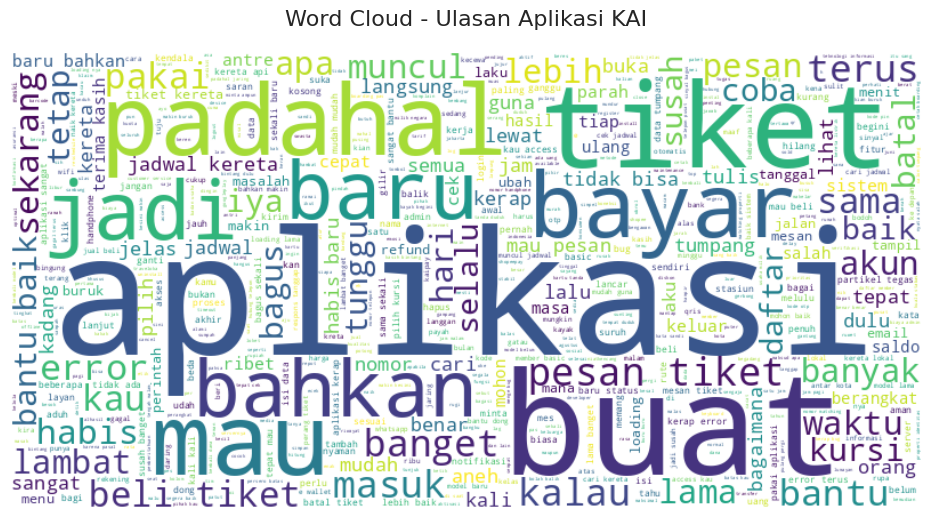

In [ ]:
all_words = ' '.join([text for text in data['final_sentence'].dropna()])
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=1000,
    colormap='viridis'
).generate(all_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Ulasan Aplikasi KAI', fontsize=16, pad=20)
plt.tight_layout(pad=0)
plt.show()

In [ ]:
data_final.to_csv("data_cleaning.csv",index=False)